# Parallel execution: determinism, speed-up and memory

The engine divides the nodes of each frame among `n_workers` threads (Section 4.3.10). This notebook
answers the two questions Chapter 4 leaves to Chapter 5:

1. **Determinism.** In direct correlation every node is computed independently, so the displacement and
   strain fields must be *identical*, not merely close, for any number of workers. Any difference would be
   a thread-safety defect. Incremental correlation is checked too, since there each frame depends on the
   previous one.
2. **Speed-up and memory.** How much faster is a run with more workers, and what does it cost in memory?
   The engine is written in Python, and the interpreter runs one thread at a time except inside compiled
   routines (NumPy, SciPy, OpenCV), so a speed-up well below the number of cores is expected; it is
   measured here rather than assumed.

The images are synthetic (`examples/synthetic.py`) so the notebook needs no external data. The engine is
called through the public interface, not the CLI: the CLI would add interpreter start-up to every timing.
Timings depend on the machine and its load, so the notebook is meant to run from a fresh kernel with
nothing else heavy running.

In [9]:
import dataclasses
import os
import platform
import sys
import time
import tracemalloc
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

REPO = Path.cwd().parent if Path.cwd().name == "benchmarks" else Path.cwd()
sys.path.insert(0, str(REPO / "examples"))   # synthetic.py lives beside the API walkthrough

import icorrvision as ic
from synthetic import affine_warp, speckle, translate

RESULTS = Path(os.environ.get("DIC_RESULTS", "~/Documents/dicresults-clean")).expanduser() / "parallel"
RESULTS.mkdir(parents=True, exist_ok=True)

## Machine

QR2 requires measurements "on stated hardware"; the hardware and software used are printed below.

In [10]:
def cpu_name() -> str:
    try:
        for line in Path("/proc/cpuinfo").read_text().splitlines():
            if line.startswith("model name"):
                return line.split(":", 1)[1].strip()
    except OSError:
        pass
    return platform.processor() or "unknown"


def distribution() -> str:
    try:
        fields = dict(line.split("=", 1) for line in Path("/etc/os-release").read_text().splitlines() if "=" in line)
        return fields.get("PRETTY_NAME", "unknown").strip('"')
    except OSError:
        return platform.system()


machine = {
    "cpu": cpu_name(),
    "logical_cores": os.cpu_count(),
    "distribution": distribution(),
    "kernel": platform.release(),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "opencv": cv2.__version__,
    "icorrvision": ic.__version__,
}
for k, v in machine.items():
    print(f"{k:14s} {v}")

cpu            AMD Ryzen 9 5900X 12-Core Processor
logical_cores  24
distribution   NixOS 26.11 (Zokor)
kernel         7.2.4
python         3.12.13
numpy          2.5.3
scipy          1.18.1
opencv         5.0.0
icorrvision    2.0.0


## The workload

A 600 × 600 speckle image and three deformed frames, each a uniform stretch plus a sub-pixel translation,
correlated with the default configuration: subset 21, step 6 (about 9 000 nodes per frame), biquintic
interpolation, meshfree strain. A single-worker frame then takes of the order of 15–20 s, long enough to
time reliably, and the whole notebook runs in roughly 20–30 minutes with one worker as the slowest case.
Change `SIZE`, `STEP` or `N_FRAMES` to trade run time against the stability of the timings.

In [11]:
SIZE, STEP, SUBSET, N_FRAMES = 600, 6, 21, 3
WORKERS = [1, 2, 4, 8]
REPEATS = 3

reference = speckle(SIZE, SIZE, seed=11)
frames = {}
for k in range(1, N_FRAMES + 1):
    stretched = affine_warp(reference, 0.002 * k, -0.0006 * k, 0.0)
    frames[f"frame_{k:02d}"] = translate(stretched, dx=0.13 * k, dy=-0.07 * k)

setup = ic.SetupOutput(
    reference_frame=reference,
    roi_mask=np.ones(reference.shape, dtype=bool),
    subset_size=SUBSET,
    step_size=STEP,
    deformed_list=list(frames),
)
base = ic.CorrelationConfig(search_size=SUBSET + 10)


def run(config):
    return ic.build_engine(config, setup, frames.__getitem__).run()


nodes = run(dataclasses.replace(base, n_workers=1)).frames[0].valid_mask.sum()
print(f"{nodes} nodes per frame, {N_FRAMES} frames")

9409 nodes per frame, 3 frames


## 1. Determinism

Every field of every frame is compared with the single-worker result using `np.array_equal`, which also
requires NaNs in the same places. Strain is compared as well, since it is computed from the displacement.

In [12]:
FIELDS = ("u_px", "v_px", "valid_mask")
STRAIN = ("exx", "eyy", "exy")


def identical(a, b) -> bool:
    for fa, fb in zip(a.frames, b.frames):
        for name in FIELDS:
            if not np.array_equal(getattr(fa, name), getattr(fb, name), equal_nan=name != "valid_mask"):
                return False
        for name in STRAIN:
            if not np.array_equal(getattr(fa.strain, name), getattr(fb.strain, name), equal_nan=True):
                return False
    return True


determinism = []
modes = {
    "direct": base,
    "incremental": dataclasses.replace(base, correlation_mode="incremental", tracking_mode="lagrangian"),
}
for mode, config in modes.items():
    single = run(dataclasses.replace(config, n_workers=1))
    for workers in WORKERS[1:]:
        same = identical(single, run(dataclasses.replace(config, n_workers=workers)))
        determinism.append({"mode": mode, "workers": workers, "identical_to_1_worker": same})
determinism = pd.DataFrame(determinism)
print(determinism.to_string(index=False))
assert determinism.identical_to_1_worker.all(), "results depend on the number of workers"

       mode  workers  identical_to_1_worker
     direct        2                   True
     direct        4                   True
     direct        8                   True
incremental        2                   True
incremental        4                   True
incremental        8                   True


## 2. Speed-up and memory

Each configuration is run `REPEATS` times and the median is reported, which is robust to a single slow run.
The time is the engine's own per-frame time (`frame_times_sec`), which excludes start-up and the reference
frame. Speed-up is relative to one worker; efficiency is speed-up divided by the number of workers.

Peak memory is traced with `tracemalloc`, which sees the allocations made through Python and NumPy but not
those made inside OpenCV's own allocator. It is therefore a lower bound, adequate for comparing worker
counts with each other, not an absolute footprint. Tracing slows execution, so memory is measured in a
separate run from the timings.

In [13]:
rows = []
for workers in WORKERS:
    config = dataclasses.replace(base, n_workers=workers)
    times = []
    for _ in range(REPEATS):
        result = run(config)
        times.append(sum(result.frame_times_sec) / len(result.frame_times_sec))
    tracemalloc.start()
    run(config)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rows.append({"workers": workers, "seconds_per_frame": float(np.median(times)),
                 "spread_s": float(np.max(times) - np.min(times)), "peak_traced_MB": peak / 2**20})

scaling = pd.DataFrame(rows)
t1 = scaling.loc[scaling.workers == 1, "seconds_per_frame"].item()
scaling["speed_up"] = t1 / scaling.seconds_per_frame
scaling["efficiency"] = scaling.speed_up / scaling.workers
scaling["nodes_per_second"] = nodes / scaling.seconds_per_frame
scaling.round(3)

,workers,seconds_per_frame,spread_s,peak_traced_MB,speed_up,efficiency,nodes_per_second
0,1,7.035,0.045,13.846,1.000,1.000,1337.464
1,2,6.071,0.043,13.849,1.159,0.579,1549.798
2,4,6.593,0.145,13.863,1.067,0.267,1427.086
3,8,6.931,0.100,13.871,1.015,0.127,1357.460


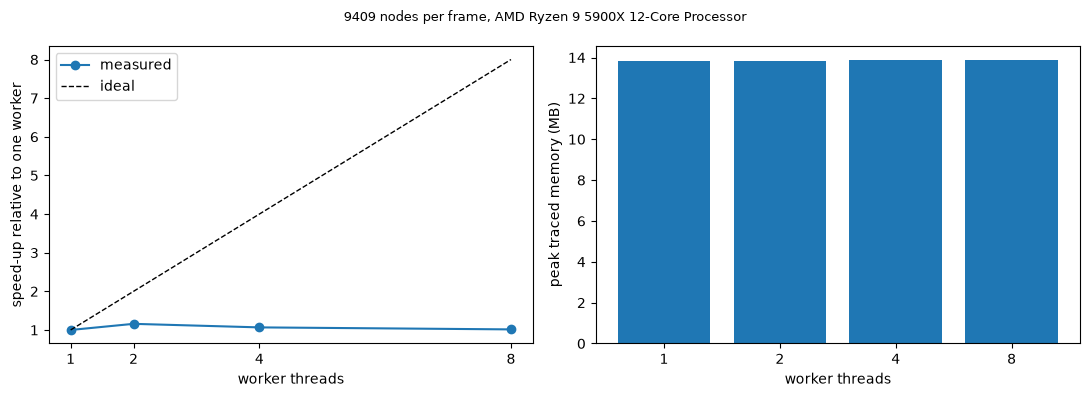

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(scaling.workers, scaling.speed_up, "o-", label="measured")
ax1.plot(scaling.workers, scaling.workers, "k--", lw=1, label="ideal")
ax1.set_xlabel("worker threads")
ax1.set_ylabel("speed-up relative to one worker")
ax1.set_xticks(WORKERS)
ax1.legend()
ax2.bar([str(w) for w in scaling.workers], scaling.peak_traced_MB)
ax2.set_xlabel("worker threads")
ax2.set_ylabel("peak traced memory (MB)")
fig.suptitle(f"{nodes} nodes per frame, {machine['cpu']}", fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / "parallel_scaling.pdf")

## Reading the result

- **Determinism** must hold without exception. If it fails, the engine is not safe to run with more than
  one worker, whatever the speed-up, and no timing is meaningful until the defect is fixed.
- **Speed-up.** Well below the number of workers is the expected outcome for per-node logic written in
  Python. The ratio shows how much of each node's work runs inside compiled routines that release the
  interpreter lock. A plateau at two to three is not a defect of the engine's parallel structure; it is
  the argument for the compiled-extension route of Section 3.8.4.
- **Memory** should grow only mildly with the number of workers, since each worker holds only one subset
  and its interpolation window at a time.

In [15]:
scaling.to_csv(RESULTS / "parallel_scaling.csv", index=False)
determinism.to_csv(RESULTS / "parallel_determinism.csv", index=False)
pd.Series(machine).to_csv(RESULTS / "parallel_machine.csv", header=["value"])
for f in ("parallel_scaling.csv", "parallel_determinism.csv", "parallel_machine.csv", "parallel_scaling.pdf"):
    print("wrote", RESULTS / f)